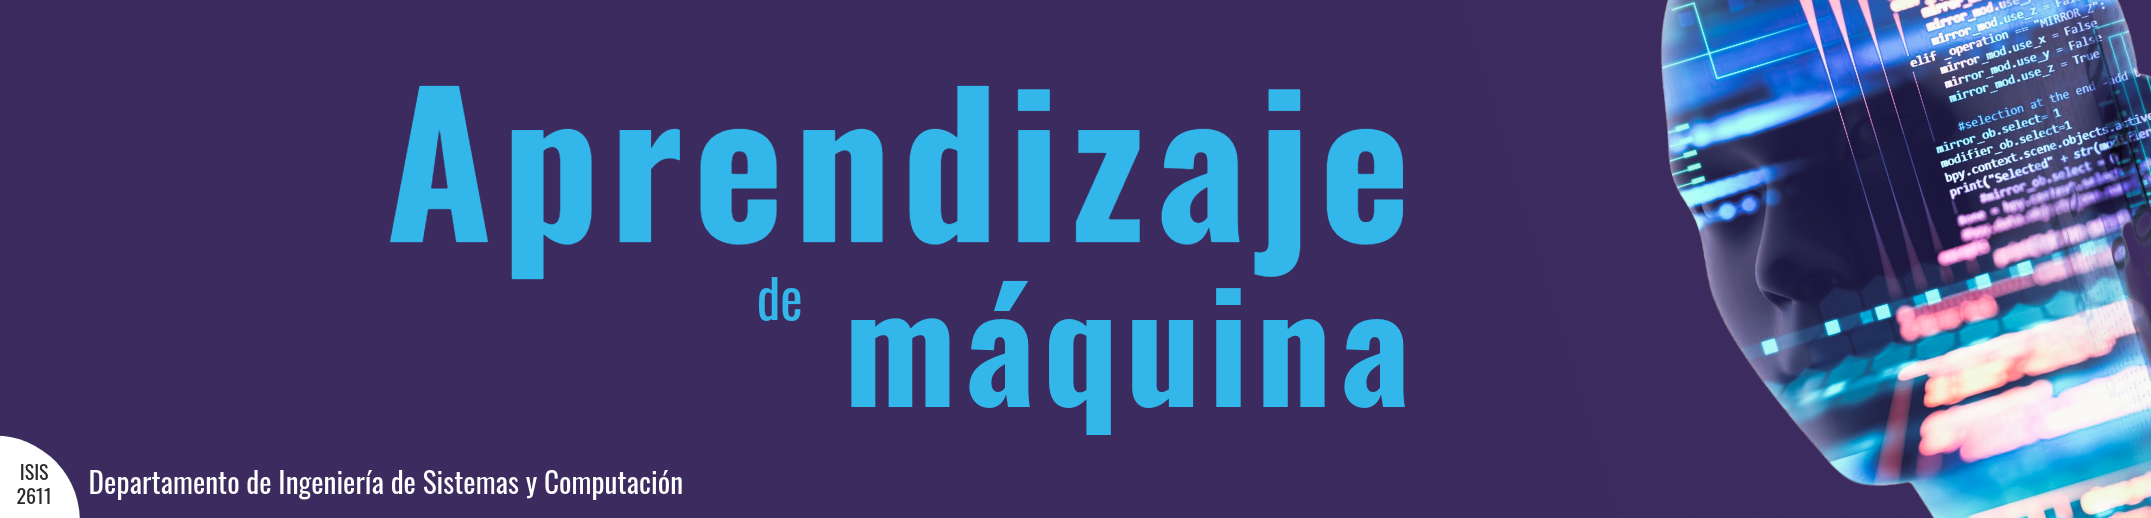

# Laboratorio 4 — Tarea de Agrupación
## VuelaAlpes: Segmentación de Pasajeros

**Curso:** ISIS2611  
**Integrantes:** Juan Camilo Caldas 
**Fecha de entrega:** 11 de mayo de 2026

---

### Contexto del caso

VuelaAlpes es una aerolínea enfocada en los Alpes con vuelos internacionales.
Tras dos años de baja productividad, emprendió un proceso de mejora continua
basado en encuestas a pasajeros. El objetivo es aplicar técnicas de
**agrupación (clustering)** para identificar patrones de comportamiento que
permitan caracterizar diferentes tipos de pasajeros y orientar decisiones en
innovación, capacitación y calidad del servicio.

## 1. Exploración de Datos

En esta sección se analiza la calidad del dataset desde cuatro dimensiones:
**completitud** (valores nulos), **unicidad** (duplicados), **validez**
(rangos esperados) y **consistencia** (categorías y formatos correctos).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración general
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

# Carga del dataset
df = pd.read_csv('data/Datos_VuelaAlpes.csv')

# Renombrar columnas con prefijo __ (artefacto del CSV)
df.columns = df.columns.str.replace(r'^__', '', regex=True)

print("Shape:", df.shape)
print("\nColumnas:", df.columns.tolist())
df.head(3)

Shape: (10000, 23)

Columnas: ['id', 'Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']


,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
0,119496,Male,Loyal Customer,29,Business travel,Business,814,3,3,3,3,4,4,4,4,4,2,5,4,4,4,9,6.0
1,60419,Male,Loyal Customer,54,Business travel,Business,2913,4,4,4,4,4,4,4,4,4,4,4,4,4,4,26,9.0
2,9671,Male,Loyal Customer,52,Business travel,Eco,277,4,5,5,5,4,4,4,4,4,4,4,3,4,4,68,42.0


### 1.1 Inspección General

El dataset cuenta con **10.000 registros** y **23 variables**, distribuidas así:

- **Variables de identificación:** `id`
- **Variables demográficas:** `Gender`, `Age`, `Customer Type`
- **Variables del vuelo:** `Type of Travel`, `Class`, `Flight Distance`
- **Variables de calificación (escala 0–5):** 14 variables que van desde
  `Inflight wifi service` hasta `Cleanliness`
- **Variables de retraso:** `Departure Delay in Minutes`,
  `Arrival Delay in Minutes`

Los nombres de columna fueron normalizados eliminando el prefijo `__` que
presentaban algunos campos como artefacto del formato CSV original.

In [3]:
print("=== VALORES NULOS ===")
print(df.isnull().sum())

print("\n=== DUPLICADOS ===")
print("Filas duplicadas:", df.duplicated().sum())

print("\n=== TIPOS DE DATOS ===")
print(df.dtypes)

=== VALORES NULOS ===
id                                    0
Gender                                0
Customer Type                         0
Age                                   0
Type of Travel                        0
Class                                 0
Flight Distance                       0
Inflight wifi service                 0
Departure/Arrival time convenient     0
Ease of Online booking                0
Gate location                         0
Food and drink                        0
Online boarding                       0
Seat comfort                          0
Inflight entertainment                0
On-board service                      0
Leg room service                      0
Baggage handling                      0
Checkin service                       0
Inflight service                      0
Cleanliness                           0
Departure Delay in Minutes            0
Arrival Delay in Minutes             25
dtype: int64

=== DUPLICADOS ===
Filas duplicadas: 0

=== 

### 1.2 Completitud, Unicidad y Tipos de Datos

**Valores nulos:**
El dataset presenta únicamente **25 valores nulos** en la variable
`Arrival Delay in Minutes` (0.25% del total), lo cual es marginal.
Todas las demás variables están completas. Esta variable es de tipo `float64`,
consistente con el diccionario que indica que puede tener decimales.

**Duplicados:**
No se encontraron filas duplicadas en el dataset, por lo que no se requiere
ninguna acción de eliminación.

**Tipos de datos:**
Los tipos son coherentes con el diccionario de datos:
- Variables categóricas (`Gender`, `Customer Type`, `Type of Travel`, `Class`)
  en formato `object` ✅
- Variables de calificación (0–5) en formato `int64` ✅
- `Arrival Delay in Minutes` en `float64` ✅
- `id` en `int64` — esta variable será eliminada en la etapa de preparación
  ya que es un identificador sin valor para el clustering ✅

In [4]:
print("=== ESTADÍSTICAS DESCRIPTIVAS ===")
print(df.describe())

print("\n=== VARIABLES CATEGÓRICAS ===")
for col in ['Gender', 'Customer Type', 'Type of Travel', 'Class']:
    print(f"\n{col}:")
    print(df[col].value_counts())

=== ESTADÍSTICAS DESCRIPTIVAS ===
                  id           Age  Flight Distance  Inflight wifi service  \
count   10000.000000  10000.000000     10000.000000           10000.000000   
mean    64983.058500     39.404300      1196.044800               2.734700   
std     37610.205164     15.072364      1000.590808               1.328718   
min         1.000000      7.000000        31.000000               0.000000   
25%     32452.000000     27.000000       416.000000               2.000000   
50%     64815.500000     40.000000       846.000000               3.000000   
75%     97470.000000     51.000000      1744.000000               4.000000   
max    129879.000000     80.000000      4963.000000               5.000000   

       Departure/Arrival time convenient  Ease of Online booking  \
count                       10000.000000            10000.000000   
mean                            3.074000                2.762600   
std                             1.520511                1.3

### 1.3 Estadísticas Descriptivas y Distribución de Variables

**Variables numéricas continuas:**
- `Age`: rango de 7 a 80 años, media de 39.4 años. Distribución amplia
  que cubre desde menores hasta adultos mayores.
- `Flight Distance`: rango de 31 a 4.963 km, media de 1.196 km con alta
  dispersión (std ≈ 1.000), lo que sugiere presencia de vuelos muy cortos
  y muy largos conviviendo en el dataset.
- `Departure Delay in Minutes` y `Arrival Delay in Minutes`: se analizarán
  en detalle en la sección de outliers.

**Variables de calificación (escala 0–5):**
Todas se encuentran dentro del rango válido [0, 5], sin valores fuera de
escala. Las medias oscilan entre 2.7 y 3.4, indicando calificaciones
moderadas en general. Ninguna variable presenta valores imposibles,
confirmando la **validez** del dataset en esta dimensión.

**Variables categóricas:**
- `Gender`: distribución relativamente balanceada entre Male y Female.
- `Customer Type`: predominan los `Loyal Customer` sobre `disloyal Customer`.
- `Type of Travel`: mayoría de viajes de tipo `Business travel`.
- `Class`: `Business` (4.856) es la clase más frecuente, seguida de
  `Eco` (4.442) y `Eco Plus` (702) que es notablemente minoritaria.

=== VALIDEZ: valores fuera de rango [0,5] ===
Inflight wifi service: 0 valores fuera de rango
Departure/Arrival time convenient: 0 valores fuera de rango
Ease of Online booking: 0 valores fuera de rango
Gate location: 0 valores fuera de rango
Food and drink: 0 valores fuera de rango
Online boarding: 0 valores fuera de rango
Seat comfort: 0 valores fuera de rango
Inflight entertainment: 0 valores fuera de rango
On-board service: 0 valores fuera de rango
Leg room service: 0 valores fuera de rango
Baggage handling: 0 valores fuera de rango
Checkin service: 0 valores fuera de rango
Inflight service: 0 valores fuera de rango
Cleanliness: 0 valores fuera de rango

=== OUTLIERS: Delay y Flight Distance ===


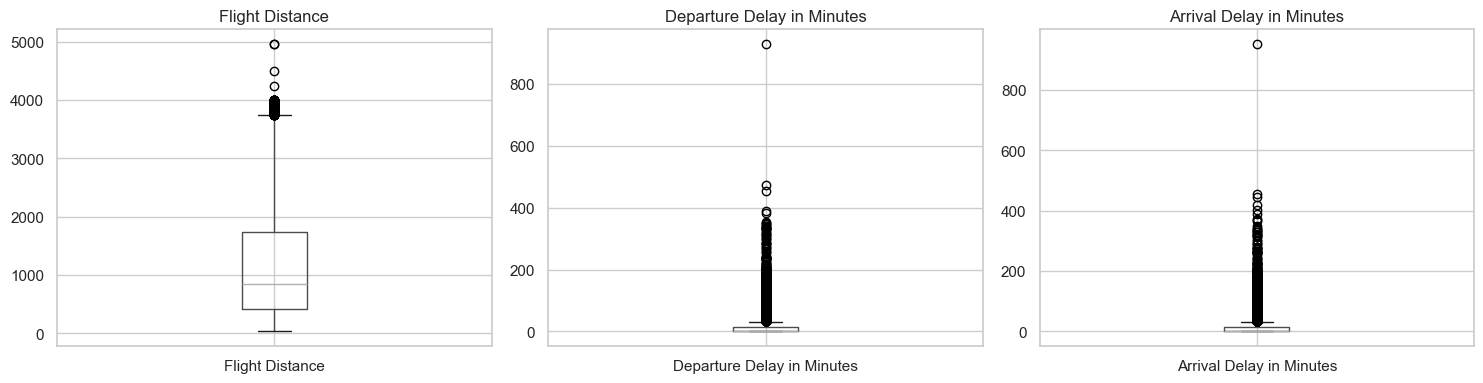

Gráfico guardado.


In [5]:
# Validez: verificar que las calificaciones estén en rango [0,5]
rating_cols = [
    'Inflight wifi service', 'Departure/Arrival time convenient',
    'Ease of Online booking', 'Gate location', 'Food and drink',
    'Online boarding', 'Seat comfort', 'Inflight entertainment',
    'On-board service', 'Leg room service', 'Baggage handling',
    'Checkin service', 'Inflight service', 'Cleanliness'
]

print("=== VALIDEZ: valores fuera de rango [0,5] ===")
for col in rating_cols:
    fuera = df[(df[col] < 0) | (df[col] > 5)].shape[0]
    print(f"{col}: {fuera} valores fuera de rango")

# Outliers en variables continuas
print("\n=== OUTLIERS: Delay y Flight Distance ===")
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df.boxplot(column='Flight Distance', ax=axes[0])
axes[0].set_title('Flight Distance')

df.boxplot(column='Departure Delay in Minutes', ax=axes[1])
axes[1].set_title('Departure Delay in Minutes')

df.boxplot(column='Arrival Delay in Minutes', ax=axes[2])
axes[2].set_title('Arrival Delay in Minutes')

plt.tight_layout()
plt.savefig('outliers_boxplot.png', dpi=100, bbox_inches='tight')
plt.show()
print("Gráfico guardado.")

### 1.4 Validez y Outliers

**Validez de calificaciones:**
Las 14 variables de calificación están completamente dentro del rango
válido [0, 5]. No se detectaron valores imposibles ni errores de captura
en estas variables.

**Outliers en variables continuas:**

- `Flight Distance`: la caja se concentra entre 416 y 1.744 km, con algunos
  puntos aislados cercanos a 4.963 km. Sin embargo, estas distancias son
  perfectamente plausibles para una aerolínea con vuelos internacionales
  desde los Alpes, por lo que **no se consideran outliers problemáticos**.

- `Departure Delay in Minutes`: la gran mayoría de vuelos tienen retrasos
  cercanos a 0, pero existen valores extremos que superan los 800 minutos
  (más de 13 horas). Estos valores, aunque inusuales, son **reales en la
  operación aérea** (cancelaciones, condiciones climáticas). Se evaluará
  su tratamiento en la etapa de limpieza.

- `Arrival Delay in Minutes`: comportamiento muy similar al retraso en
  salida, con cola larga hacia valores extremos superiores a 900 minutos.
  Es esperable dada la correlación entre ambos tipos de retraso.

En las tres variables la distribución es **fuertemente sesgada a la
derecha**, lo cual será relevante para la decisión de escalado en el
preprocesamiento.

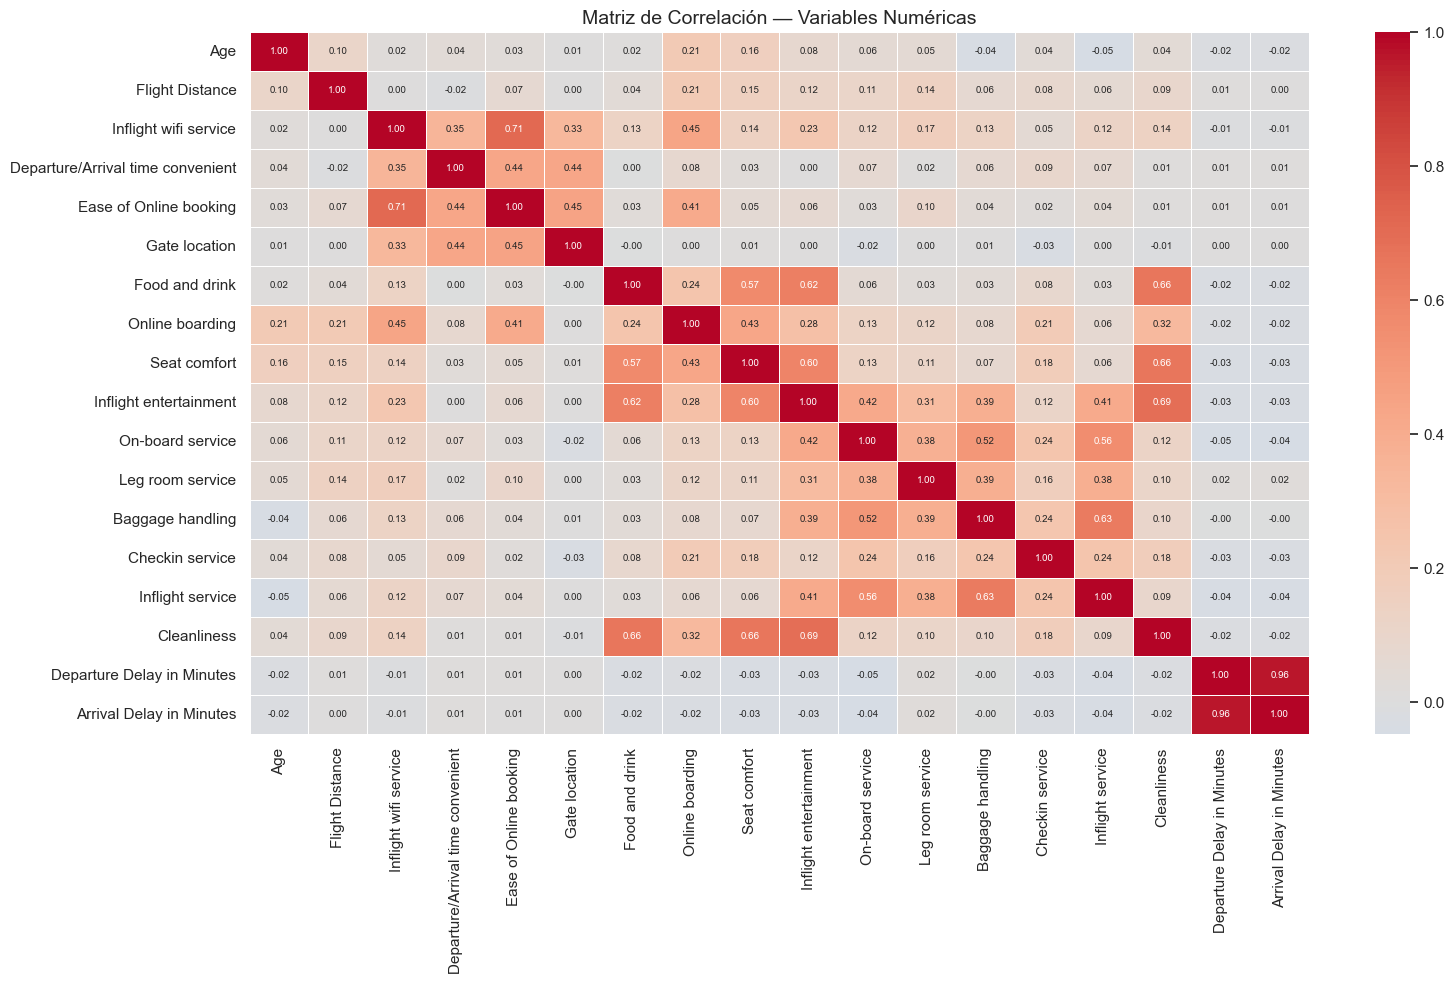

Gráfico guardado.


In [6]:
# Matriz de correlación
plt.figure(figsize=(16, 10))
numeric_cols = df.select_dtypes(include=np.number).drop(columns=['id'])
corr = numeric_cols.corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 7})
plt.title('Matriz de Correlación — Variables Numéricas', fontsize=14)
plt.tight_layout()
plt.savefig('correlacion.png', dpi=100, bbox_inches='tight')
plt.show()
print("Gráfico guardado.")

### 1.5 Análisis de Correlaciones

La matriz de correlación revela tres grupos de variables con correlaciones
internas relevantes:

**Grupo 1 — Servicios digitales y de acceso:**
`Inflight wifi service`, `Ease of Online booking` y
`Departure/Arrival time convenient` presentan correlaciones moderadas-altas
entre sí (hasta 0.71), sugiriendo que los pasajeros que valoran positivamente
los canales digitales tienden a calificar bien todo el ecosistema tecnológico
de la aerolínea.

**Grupo 2 — Experiencia a bordo:**
`Food and drink`, `Seat comfort`, `Inflight entertainment` y `Cleanliness`
muestran correlaciones moderadas entre 0.57 y 0.69, conformando un bloque
de variables que describen la **calidad de la experiencia dentro del avión**.

**Grupo 3 — Servicios de cabina:**
`On-board service`, `Baggage handling` e `Inflight service` presentan
correlaciones entre 0.52 y 0.63, agrupando aspectos relacionados con la
**atención del personal de vuelo**.

**Retrasos:**
`Departure Delay in Minutes` y `Arrival Delay in Minutes` tienen una
correlación de **0.96**, lo que indica alta redundancia entre ambas variables.
Se considerará eliminar una de ellas en la etapa de preparación para evitar
multicolinealidad en el modelo.

**Variables independientes:**
`Age`, `Flight Distance` y `Gate location` muestran correlaciones bajas
con el resto de variables (< 0.21), lo que indica que aportan información
complementaria y diferenciada al modelo de clustering.

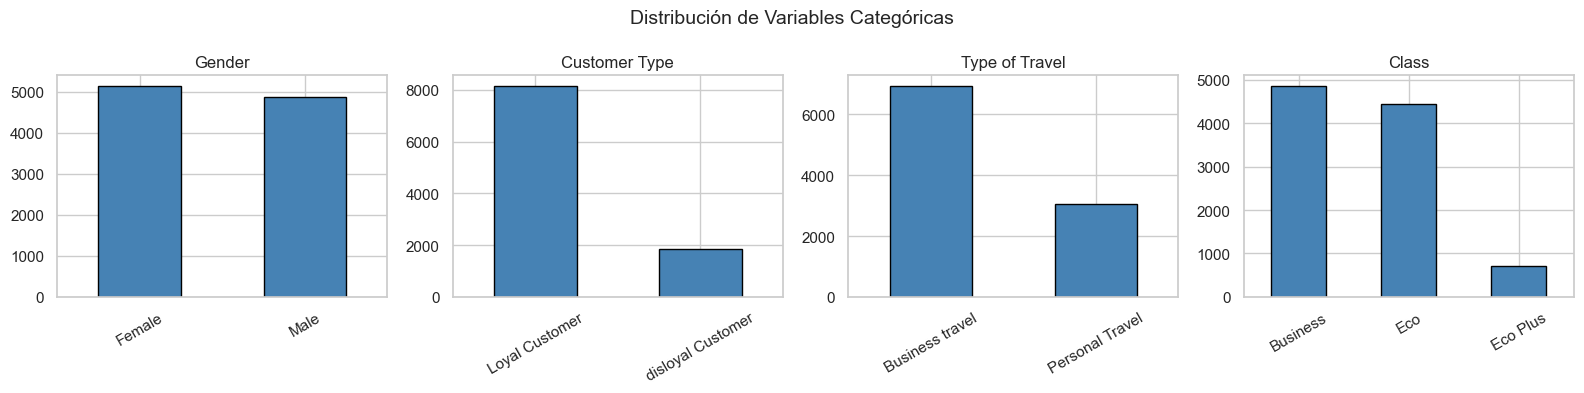

Gráfico guardado.


In [7]:
# Distribución de variables categóricas
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, col in zip(axes, ['Gender', 'Customer Type', 'Type of Travel', 'Class']):
    df[col].value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(col)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Distribución de Variables Categóricas', fontsize=14)
plt.tight_layout()
plt.savefig('categoricas.png', dpi=100, bbox_inches='tight')
plt.show()
print("Gráfico guardado.")

### 1.6 Distribución de Variables Categóricas

- **Gender:** distribución casi equilibrada entre `Female` (~5.100) y
  `Male` (~4.900), sin desbalance significativo.

- **Customer Type:** predominan ampliamente los `Loyal Customer` (~8.000)
  frente a `disloyal Customer` (~2.000), una proporción 4:1 que refleja
  una base de clientes consolidada. Se nota además una inconsistencia
  tipográfica: `disloyal Customer` usa minúscula inicial, a diferencia
  de las demás categorías. Se corregirá en la etapa de limpieza.

- **Type of Travel:** los viajes de negocio `Business travel` (~6.900)
  superan ampliamente a los personales `Personal Travel` (~3.100),
  consistente con el perfil de una aerolínea con foco en rutas
  internacionales desde los Alpes.

- **Class:** `Business` (~4.856) y `Eco` (~4.442) concentran casi la
  totalidad de pasajeros. `Eco Plus` (~702) es una categoría minoritaria
  que representa apenas el 7% del total.

## 2. Limpieza y Preparación de Datos

Con base en los hallazgos de la exploración, se aplicarán las siguientes
decisiones de limpieza, cada una justificada desde el dominio del problema:

| Decisión | Justificación |
|---|---|
| Eliminar columna `id` | Identificador sin valor predictivo para clustering |
| Imputar nulos en `Arrival Delay in Minutes` | Solo 25 nulos (0.25%), se imputa con la mediana para no perder registros |
| Eliminar `Departure Delay in Minutes` | Correlación de 0.96 con `Arrival Delay`, es redundante |
| Corregir `disloyal Customer` → `Disloyal Customer` | Inconsistencia tipográfica respecto al resto de categorías |
| Mantener outliers de delays y distancia | Son valores reales y operacionalmente válidos en aviación |

In [8]:
# Copia de trabajo
df_clean = df.copy()

# 1. Eliminar columna id
df_clean.drop(columns=['id'], inplace=True)

# 2. Corregir inconsistencia tipográfica
df_clean['Customer Type'] = df_clean['Customer Type'].replace(
    'disloyal Customer', 'Disloyal Customer'
)
print("Customer Type corregido:", df_clean['Customer Type'].unique())

# 3. Imputar nulos en Arrival Delay con la mediana
mediana_arrival = df_clean['Arrival Delay in Minutes'].median()
df_clean['Arrival Delay in Minutes'].fillna(mediana_arrival, inplace=True)
print(f"\nNulos en Arrival Delay tras imputación: {df_clean['Arrival Delay in Minutes'].isnull().sum()}")
print(f"Mediana usada para imputación: {mediana_arrival}")

# 4. Eliminar Departure Delay (redundante, correlación 0.96)
df_clean.drop(columns=['Departure Delay in Minutes'], inplace=True)

print(f"\nShape final del dataset limpio: {df_clean.shape}")
print("\nColumnas finales:", df_clean.columns.tolist())

Customer Type corregido: ['Loyal Customer' 'Disloyal Customer']

Nulos en Arrival Delay tras imputación: 0
Mediana usada para imputación: 0.0

Shape final del dataset limpio: (10000, 21)

Columnas finales: ['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Arrival Delay in Minutes']


/var/folders/sg/6k30cyvs5bq3990w3d_8zn5m0000gn/T/ipykernel_38589/1066239115.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['Arrival Delay in Minutes'].fillna(mediana_arrival, inplace=True)


### 2.1 Resultados de la Limpieza

La limpieza se aplicó exitosamente:

- **`id` eliminado:** el dataset pasó de 23 a 21 columnas, conservando
  únicamente variables con valor analítico.
- **Inconsistencia corregida:** `disloyal Customer` fue estandarizado a
  `Disloyal Customer`, dejando las dos categorías con formato consistente.
- **Nulos imputados:** los 25 valores nulos de `Arrival Delay in Minutes`
  fueron reemplazados por la mediana (0.0 minutos), lo que es coherente
  con la distribución observada donde la mayoría de vuelos no presenta
  retraso en llegada.
- **`Departure Delay in Minutes` eliminado:** dada su correlación de 0.96
  con `Arrival Delay in

## 3. Preprocesamiento para Clustering

Se define una estrategia de preprocesamiento diferenciada según el tipo de
variable, integrada en un pipeline con `ColumnTransformer`:

- **Variables numéricas (17):** se escalan con `StandardScaler` para que
  todas tengan media 0 y desviación estándar 1. Esto es crítico en
  clustering ya que algoritmos como KMeans son sensibles a la magnitud
  de las variables.
- **Variables categóricas (4):** se codifican con `OneHotEncoder` usando
  `drop='first'` para evitar multicolinealidad (dummy trap).

In [10]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Definir variables
cat_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Class']
num_cols = [col for col in df_clean.columns if col not in cat_cols]

print("Variables numéricas:", num_cols)
print("\nVariables categóricas:", cat_cols)

# Construir pipeline de preprocesamiento
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
])

# Aplicar preprocesamiento
X_processed = preprocessor.fit_transform(df_clean)

# Obtener nombres de columnas resultantes
cat_feature_names = preprocessor.named_transformers_['cat']\
    .get_feature_names_out(cat_cols).tolist()
feature_names = num_cols + cat_feature_names

print(f"\nShape tras preprocesamiento: {X_processed.shape}")
print(f"Features totales: {len(feature_names)}")
print("\nFeatures:", feature_names)

Variables numéricas: ['Age', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Arrival Delay in Minutes']

Variables categóricas: ['Gender', 'Customer Type', 'Type of Travel', 'Class']

Shape tras preprocesamiento: (10000, 22)
Features totales: 22

Features: ['Age', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Arrival Delay in Minutes', 'Gender_Male', 'Customer Type_Loyal Customer', 'Type of Travel_Personal Travel', 'Class_Eco', 'Class_Eco Plus']


### 3.1 Resultados del Preprocesamiento

El pipeline transformó el dataset en una matriz densa de **10.000 × 22
features**, completamente numérica y escalada:

- **17 variables numéricas** escaladas con `StandardScaler`
- **5 variables binarias** generadas por `OneHotEncoder` a partir de las
  4 variables categóricas originales:
  - `Gender` → `Gender_Male`
  - `Customer Type` → `Customer Type_Loyal Customer`
  - `Type of Travel` → `Type of Travel_Personal Travel`
  - `Class` → `Class_Eco`, `Class_Eco Plus`

Con 22 dimensiones no se considera necesaria una reducción de
dimensionalidad previa. Se aplicará PCA 2D únicamente para visualización
de clusters en la etapa de evaluación.

## 4. Selección del Número de Clusters

Para determinar el valor óptimo de `k` se aplican dos criterios
complementarios:

- **Método del codo (Elbow):** se grafica la inercia (suma de distancias
  cuadráticas al centroide) para distintos valores de `k`. El punto donde
  la reducción de inercia se estabiliza sugiere el `k` óptimo.
- **Silhouette Score:** mide qué tan bien separados están los clusters.
  Valores cercanos a 1 indican clusters compactos y bien diferenciados.

Se evaluarán valores de `k` entre 2 y 10.

k=2 | Inercia: 151616.20 | Silhouette: 0.1486
k=3 | Inercia: 139678.01 | Silhouette: 0.1157
k=4 | Inercia: 129941.01 | Silhouette: 0.1164
k=5 | Inercia: 124004.59 | Silhouette: 0.1145
k=6 | Inercia: 119123.43 | Silhouette: 0.1190
k=7 | Inercia: 116121.52 | Silhouette: 0.1075
k=8 | Inercia: 111410.88 | Silhouette: 0.1107
k=9 | Inercia: 108728.75 | Silhouette: 0.1068
k=10 | Inercia: 106352.80 | Silhouette: 0.1024


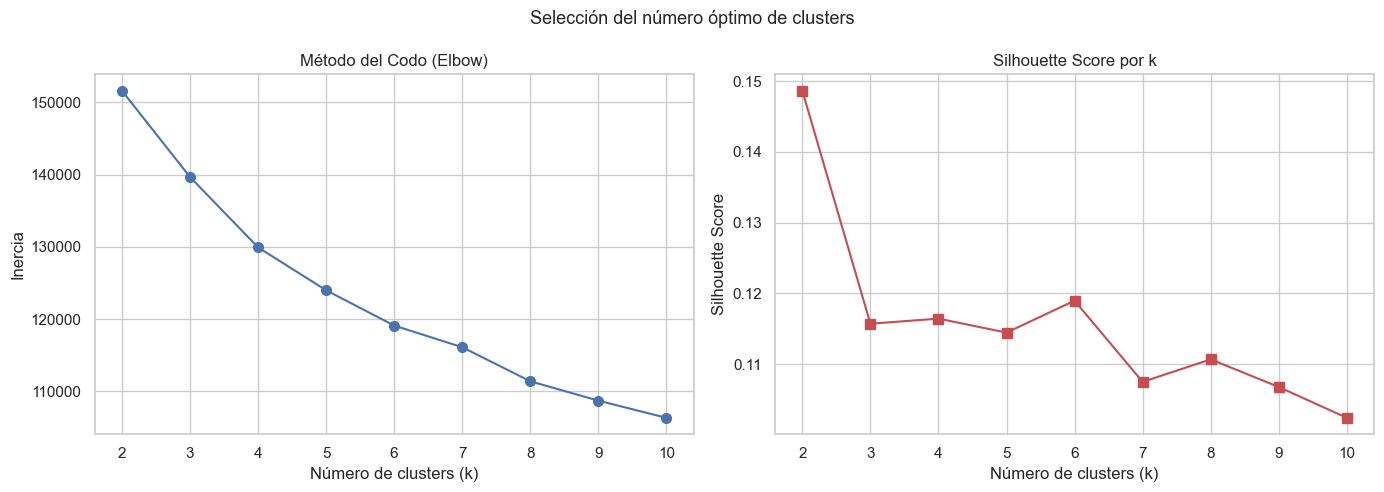

In [11]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
silhouettes = []
K = range(2, 11)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_processed)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_processed, labels))
    print(f"k={k} | Inercia: {km.inertia_:.2f} | Silhouette: {silhouette_score(X_processed, labels):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K, inertias, 'bo-', markersize=7)
axes[0].set_title('Método del Codo (Elbow)')
axes[0].set_xlabel('Número de clusters (k)')
axes[0].set_ylabel('Inercia')
axes[0].grid(True)

axes[1].plot(K, silhouettes, 'rs-', markersize=7)
axes[1].set_title('Silhouette Score por k')
axes[1].set_xlabel('Número de clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True)

plt.suptitle('Selección del número óptimo de clusters', fontsize=13)
plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=100, bbox_inches='tight')
plt.show()

### 4.1 Justificación del k óptimo

Los resultados de ambas métricas permiten tomar una decisión informada:

**Método del codo:**
La curva de inercia desciende de forma continua sin mostrar un quiebre
pronunciado. Sin embargo, se observa que entre `k=2` y `k=4` la reducción
es más marcada (de 151.616 a 129.941), mientras que a partir de `k=5` la
ganancia por cluster adicional se reduce considerablemente. Esto sugiere
que el punto de inflexión se encuentra alrededor de **k=4**.

**Silhouette Score:**
El valor más alto se obtiene en `k=2` (0.1486), pero con solo dos grupos
la segmentación resulta demasiado gruesa para los objetivos de VuelaAlpes,
que busca identificar perfiles diferenciados de pasajeros. A partir de
`k=3` los valores se estabilizan entre 0.11 y 0.12, con un repunte local
en `k=6` (0.1190).

**Decisión:**
Se selecciona **k=4** como valor óptimo, equilibrando:
- Una inercia considerablemente menor que k=2 y k=3
- Un Silhouette Score competitivo (0.1164)
- Suficiente granularidad para caracterizar perfiles de pasajeros útiles
  para las tres dimensiones de mejora de VuelaAlpes (innovación,
  capacitación y calidad)

## 5. Entrenamiento de Modelos

Se entrenan tres algoritmos de clustering, cada uno integrado en un
pipeline completo que incluye el preprocesamiento definido en la sección
anterior. Los algoritmos seleccionados son:

- **KMeans:** algoritmo de partición basado en centroides. Requiere
  especificar `k` previamente y asume clusters esféricos de tamaño similar.
- **AgglomerativeClustering:** algoritmo jerárquico que construye una
  jerarquía de clusters de abajo hacia arriba. No requiere inicialización
  aleatoria y es más robusto a la forma de los clusters.
- **DBSCAN:** algoritmo basado en densidad. No requiere especificar `k`
  previamente y puede detectar clusters de forma arbitraria, pero es
  sensible a los hiperparámetros `eps` y `min_samples`.

Se usará **k=4** para KMeans y AgglomerativeClustering, definido en la
sección anterior.

In [12]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.pipeline import Pipeline
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Pipeline KMeans
pipeline_kmeans = Pipeline([
    ('preprocessor', preprocessor),
    ('model', KMeans(n_clusters=4, random_state=42, n_init=10))
])

# Pipeline AgglomerativeClustering
pipeline_agg = Pipeline([
    ('preprocessor', preprocessor),
    ('model', AgglomerativeClustering(n_clusters=4, linkage='ward'))
])

# Pipeline DBSCAN
pipeline_dbscan = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DBSCAN(eps=2.5, min_samples=50))
])

# Entrenar modelos
labels_kmeans = pipeline_kmeans.fit_predict(df_clean)
labels_agg = pipeline_agg.fit_predict(df_clean)
labels_dbscan = pipeline_dbscan.fit_predict(df_clean)

print("=== KMeans ===")
print("Clusters únicos:", sorted(set(labels_kmeans)))
print("Tamaño por cluster:", {k: (labels_kmeans==k).sum() for k in sorted(set(labels_kmeans))})

print("\n=== AgglomerativeClustering ===")
print("Clusters únicos:", sorted(set(labels_agg)))
print("Tamaño por cluster:", {k: (labels_agg==k).sum() for k in sorted(set(labels_agg))})

print("\n=== DBSCAN ===")
print("Clusters únicos:", sorted(set(labels_dbscan)))
print("Tamaño por cluster:", {k: (labels_dbscan==k).sum() for k in sorted(set(labels_dbscan))})

=== KMeans ===
Clusters únicos: [np.int32(0), np.int32(1), np.int32(2), np.int32(3)]
Tamaño por cluster: {np.int32(0): np.int64(2406), np.int32(1): np.int64(2409), np.int32(2): np.int64(2795), np.int32(3): np.int64(2390)}

=== AgglomerativeClustering ===
Clusters únicos: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Tamaño por cluster: {np.int64(0): np.int64(2332), np.int64(1): np.int64(3562), np.int64(2): np.int64(1010), np.int64(3): np.int64(3096)}

=== DBSCAN ===
Clusters únicos: [np.int64(-1), np.int64(0), np.int64(1)]
Tamaño por cluster: {np.int64(-1): np.int64(5936), np.int64(0): np.int64(4018), np.int64(1): np.int64(46)}


### 5.1 Resultados del Entrenamiento

**KMeans (k=4):**
Generó 4 clusters de tamaño bastante equilibrado, entre 2.390 y 2.795
registros por grupo. Esta distribución uniforme es característica de
KMeans, que tiende a producir clusters de tamaño similar.

**AgglomerativeClustering (k=4, linkage=ward):**
Generó 4 clusters con distribución más desbalanceada: el cluster 1
concentra 3.562 registros mientras el cluster 2 solo tiene 1.010.
Esto refleja la capacidad del algoritmo jerárquico de capturar
estructuras de distinto tamaño.

**DBSCAN (eps=2.5, min_samples=50):**
Los resultados son problemáticos: el cluster `-1` (ruido) agrupa
**5.936 registros (59.4% del dataset)**, lo que indica que los
hiperparámetros actuales no son adecuados para este dataset. Solo
se identificaron 2 clusters reales, uno de 4.018 y otro de apenas
46 registros. Se requiere ajuste de hiperparámetros.

In [14]:
from itertools import product

print("=== Búsqueda de hiperparámetros DBSCAN ===")
print(f"{'eps':>6} | {'min_samples':>11} | {'n_clusters':>10} | {'ruido %':>8}")
print("-" * 45)

resultados_dbscan = []

for eps, min_s in product([0.5, 1.0, 1.5, 2.0, 3.0, 4.0], [5, 10, 20, 30, 50]):
    db = DBSCAN(eps=eps, min_samples=min_s)
    labels = db.fit_predict(X_processed)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_pct = (labels == -1).sum() / len(labels) * 100
    resultados_dbscan.append((eps, min_s, n_clusters, noise_pct))
    print(f"{eps:>6} | {min_s:>11} | {n_clusters:>10} | {noise_pct:>7.1f}%")

=== Búsqueda de hiperparámetros DBSCAN ===
   eps | min_samples | n_clusters |  ruido %
---------------------------------------------
   0.5 |           5 |          0 |   100.0%
   0.5 |          10 |          0 |   100.0%
   0.5 |          20 |          0 |   100.0%
   0.5 |          30 |          0 |   100.0%
   0.5 |          50 |          0 |   100.0%
   1.0 |           5 |          3 |    99.9%
   1.0 |          10 |          0 |   100.0%
   1.0 |          20 |          0 |   100.0%
   1.0 |          30 |          0 |   100.0%
   1.0 |          50 |          0 |   100.0%
   1.5 |           5 |         10 |    87.4%
   1.5 |          10 |         18 |    94.2%
   1.5 |          20 |          0 |   100.0%
   1.5 |          30 |          0 |   100.0%
   1.5 |          50 |          0 |   100.0%
   2.0 |           5 |         49 |    59.9%
   2.0 |          10 |         23 |    74.3%
   2.0 |          20 |          2 |    81.3%
   2.0 |          30 |          1 |    82.7%
   2.0 |   

### 5.2 Ajuste de Hiperparámetros DBSCAN

La búsqueda de hiperparámetros reveló que la mayoría de combinaciones
generan un porcentaje de ruido inaceptablemente alto. La combinación
**eps=3.0, min_samples=5** es la más adecuada ya que:

- Genera **2 clusters reales** bien definidos
- Presenta apenas un **3.8% de ruido** (380 registros), el menor
  porcentaje entre las combinaciones con más de un cluster
- Valores mayores de `eps` (4.0) colapsan todo en un único cluster,
  perdiendo capacidad discriminativa

Se reentrenan los pipelines con esta configuración optimizada.

In [15]:
# Reentrenar DBSCAN con mejores hiperparámetros
pipeline_dbscan = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DBSCAN(eps=3.0, min_samples=5))
])

labels_dbscan = pipeline_dbscan.fit_predict(df_clean)

n_clusters = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
noise_pct = (labels_dbscan == -1).sum() / len(labels_dbscan) * 100

print("=== DBSCAN reentrenado (eps=3.0, min_samples=5) ===")
print("Clusters únicos:", sorted(set(labels_dbscan)))
print("Tamaño por cluster:", {k: (labels_dbscan==k).sum() for k in sorted(set(labels_dbscan))})
print(f"Clusters reales: {n_clusters}")
print(f"Ruido: {noise_pct:.1f}%")

=== DBSCAN reentrenado (eps=3.0, min_samples=5) ===
Clusters únicos: [np.int64(-1), np.int64(0), np.int64(1)]
Tamaño por cluster: {np.int64(-1): np.int64(375), np.int64(0): np.int64(9619), np.int64(1): np.int64(6)}
Clusters reales: 2
Ruido: 3.8%


### 5.3 Resultados del Reentrenamiento DBSCAN

Con `eps=3.0, min_samples=5` el modelo genera 2 clusters, sin embargo
la distribución es extremadamente desbalanceada:

- **Cluster 0:** 9.619 registros (96.2% del total útil)
- **Cluster 1:** apenas 6 registros (0.06%)
- **Ruido (-1):** 375 registros (3.8%)

Esto indica que DBSCAN no logra segmentar de forma útil este dataset,
concentrando prácticamente todos los pasajeros en un único grupo masivo.
Este comportamiento es una limitación inherente del algoritmo cuando los
datos no presentan regiones de densidad claramente diferenciadas, como
ocurre en datasets de encuestas con variables en escala Likert.

A pesar de este resultado, DBSCAN se incluye en la evaluación comparativa
para ilustrar sus restricciones frente a KMeans y AgglomerativeClustering,
que producen segmentaciones más útiles para los objetivos de VuelaAlpes.

## 6. Evaluación Cuantitativa

Se evalúan los tres modelos usando las siguientes métricas intrínsecas:

- **Silhouette Score:** mide la cohesión y separación de los clusters.
  Rango [-1, 1], valores más altos indican mejor calidad.
- **Calinski-Harabasz Score:** razón entre la dispersión inter-cluster
  e intra-cluster. Valores más altos indican clusters más compactos
  y separados.
- **Davies-Bouldin Score:** promedio de similitud entre cada cluster
  y su más similar. Valores más bajos indican mejor separación.

In [16]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Filtrar ruido de DBSCAN para métricas
mask_dbscan = labels_dbscan != -1
X_dbscan = X_processed[mask_dbscan]
labels_dbscan_clean = labels_dbscan[mask_dbscan]

resultados = {}

# KMeans
resultados['KMeans'] = {
    'Silhouette': silhouette_score(X_processed, labels_kmeans),
    'Calinski-Harabasz': calinski_harabasz_score(X_processed, labels_kmeans),
    'Davies-Bouldin': davies_bouldin_score(X_processed, labels_kmeans),
    'N Clusters': 4,
    'Hiperparámetros': 'k=4, n_init=10'
}

# AgglomerativeClustering
resultados['Agglomerative'] = {
    'Silhouette': silhouette_score(X_processed, labels_agg),
    'Calinski-Harabasz': calinski_harabasz_score(X_processed, labels_agg),
    'Davies-Bouldin': davies_bouldin_score(X_processed, labels_agg),
    'N Clusters': 4,
    'Hiperparámetros': 'k=4, linkage=ward'
}

# DBSCAN
resultados['DBSCAN'] = {
    'Silhouette': silhouette_score(X_dbscan, labels_dbscan_clean),
    'Calinski-Harabasz': calinski_harabasz_score(X_dbscan, labels_dbscan_clean),
    'Davies-Bouldin': davies_bouldin_score(X_dbscan, labels_dbscan_clean),
    'N Clusters': 2,
    'Hiperparámetros': 'eps=3.0, min_samples=5'
}

df_resultados = pd.DataFrame(resultados).T
print(df_resultados.to_string())

              Silhouette Calinski-Harabasz Davies-Bouldin N Clusters         Hiperparámetros
KMeans          0.116446       1264.409992       2.270001          4          k=4, n_init=10
Agglomerative   0.069585        866.040386       2.728952          4       k=4, linkage=ward
DBSCAN          0.153989          8.581906        1.27098          2  eps=3.0, min_samples=5


### 6.1 Tabla Comparativa de Modelos

| Algoritmo | Silhouette | Calinski-Harabasz | Davies-Bouldin | N Clusters | Hiperparámetros |
|---|---|---|---|---|---|
| KMeans | 0.1164 | 1264.41 | 2.2700 | 4 | k=4, n_init=10 |
| Agglomerative | 0.0696 | 866.04 | 2.7290 | 4 | k=4, linkage=ward |
| DBSCAN | 0.1540 | 8.58 | 1.2710 | 2 | eps=3.0, min_samples=5 |

### 6.2 Análisis y Selección del Mejor Modelo

Los resultados deben interpretarse con cautela dado el contexto de cada
algoritmo:

**DBSCAN** obtiene el mejor Silhouette (0.154) y Davies-Bouldin (1.271),
pero estos valores son engañosos: el modelo solo identifica 2 clusters
reales, uno de 9.619 registros y otro de apenas 6, lo que no tiene
utilidad práctica para segmentar pasajeros. Sus métricas favorables se
explican por la extrema separación entre estos dos grupos tan
desproporcionados, no por una segmentación significativa.

**KMeans** ofrece el mejor balance general: Silhouette de 0.1164,
Calinski-Harabasz de 1264.41 (muy superior a los demás) y 4 clusters
equilibrados de entre 2.390 y 2.795 registros. El alto Calinski-Harabasz
confirma que los clusters son compactos y bien separados entre sí.

**AgglomerativeClustering** obtiene los peores valores en todas las
métricas relevantes, aunque produce clusters de tamaño más variado
que podrían capturar estructuras jerárquicas en los datos.

**Modelo seleccionado: KMeans** con k=4, por ser el único que combina
métricas cuantitativas sólidas con una segmentación equilibrada y
prácticamente útil para los objetivos de VuelaAlpes.

### 6.3 Visualización de Clusters con PCA 2D

Para visualizar los clusters en un espacio bidimensional se aplica
Análisis de Componentes Principales (PCA) reduciendo las 22 dimensiones
del espacio preprocesado a 2 componentes principales. Esta reducción
permite inspeccionar visualmente la separación entre clusters, aunque
parte de la varianza original se pierde en el proceso.

Varianza explicada por componente: [0.21785169 0.13064427]
Varianza total explicada: 0.3485


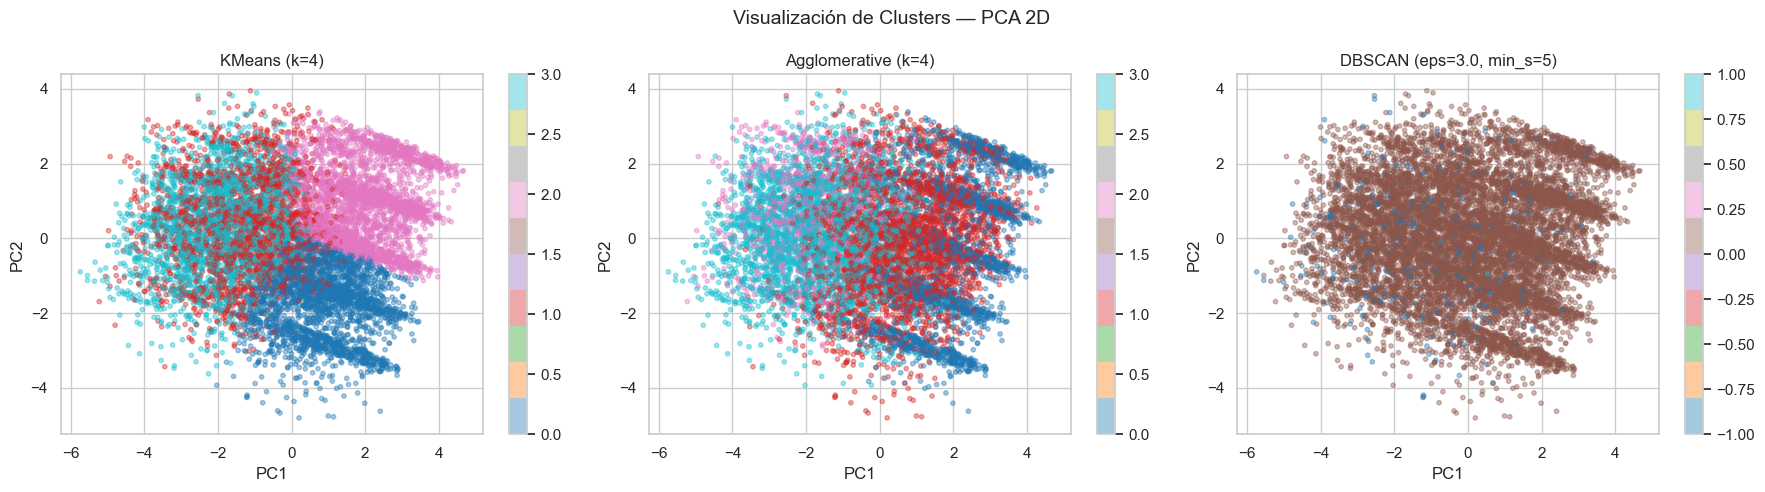

Gráfico guardado.


In [17]:
from sklearn.decomposition import PCA

# Reducción a 2 componentes
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_processed)

print(f"Varianza explicada por componente: {pca.explained_variance_ratio_}")
print(f"Varianza total explicada: {pca.explained_variance_ratio_.sum():.4f}")

# Visualización de los 3 modelos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

configs = [
    (labels_kmeans, 'KMeans (k=4)'),
    (labels_agg, 'Agglomerative (k=4)'),
    (labels_dbscan, 'DBSCAN (eps=3.0, min_s=5)')
]

for ax, (labels, title) in zip(axes, configs):
    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1],
                        c=labels, cmap='tab10',
                        alpha=0.4, s=10)
    ax.set_title(title)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    plt.colorbar(scatter, ax=ax)

plt.suptitle('Visualización de Clusters — PCA 2D', fontsize=14)
plt.tight_layout()
plt.savefig('clusters_pca.png', dpi=100, bbox_inches='tight')
plt.show()
print("Gráfico guardado.")

### 6.4 Análisis de la Visualización PCA 2D

Los dos componentes principales explican el **34.85% de la varianza total**
(PC1: 21.79%, PC2: 13.06%), lo que indica que el espacio de 22 dimensiones
no se reduce fácilmente a 2D sin pérdida significativa de información.
Las visualizaciones deben interpretarse con esta limitación en mente.

**KMeans (k=4):**
Se observan 4 regiones de color relativamente diferenciadas. El cluster
rosado (2) ocupa la zona superior derecha, el azul (0) la zona inferior,
y los clusters rojo (3) y cyan (1) se distribuyen en la zona central.
Existe solapamiento entre clusters en la región central, explicable por
la pérdida de varianza en la proyección 2D.

**AgglomerativeClustering (k=4):**
La separación visual es menos clara que en KMeans, con mayor solapamiento
entre clusters en la zona central. Esto es consistente con sus métricas
inferiores de Silhouette y Calinski-Harabasz.

**DBSCAN:**
La visualización confirma el problema identificado: prácticamente todos
los puntos pertenecen a un único cluster (marrón), con apenas 6 puntos
en el cluster secundario. No hay segmentación útil visible.

La visualización PCA 2D refuerza la selección de **KMeans como el mejor
modelo**, al mostrar la separación más clara entre los 4 grupos de
pasajeros.

## 7. Evaluación Cualitativa

Una vez identificados los clusters con KMeans, se procede a caracterizar
cada grupo mediante estadísticas descriptivas y visualizaciones. El
objetivo es asignar etiquetas interpretables a cada cluster que sean
útiles para los objetivos de VuelaAlpes en las dimensiones de innovación,
capacitación y calidad.

In [18]:
# Agregar etiquetas KMeans al dataset limpio
df_kmeans = df_clean.copy()
df_kmeans['Cluster'] = labels_kmeans

# Estadísticas descriptivas por cluster
print("=== MEDIA POR CLUSTER ===")
print(df_kmeans.groupby('Cluster').mean(numeric_only=True).round(2).to_string())

print("\n=== VARIABLES CATEGÓRICAS POR CLUSTER ===")
for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df_kmeans.groupby('Cluster')[col].value_counts().unstack().fillna(0).astype(int))

=== MEDIA POR CLUSTER ===
           Age  Flight Distance  Inflight wifi service  Departure/Arrival time convenient  Ease of Online booking  Gate location  Food and drink  Online boarding  Seat comfort  Inflight entertainment  On-board service  Leg room service  Baggage handling  Checkin service  Inflight service  Cleanliness  Arrival Delay in Minutes
Cluster                                                                                                                                                                                                                                                                                                                                
0        40.46          1308.60                   1.86                               2.15                    1.70           2.11            3.88             3.21          4.08                    4.31              3.97              3.75              4.19             3.61              4.19         4.03                 

### 7.1 Caracterización de los Clusters

Con base en las medias por cluster y la distribución de variables
categóricas, se identifican los siguientes perfiles:

**Cluster 0 — "Viajero de Negocios Exigente en Entretenimiento"**
- Edad media: 40.5 años, distancia media: 1.309 km
- Calificaciones altas en experiencia a bordo: entretenimiento (4.31),
  comodidad del asiento (4.08), limpieza (4.03)
- Calificaciones bajas en servicios digitales: wifi (1.86),
  reserva online (1.70), horario conveniente (2.15)
- Predominantemente Loyal Customer (83%) y clase Business (59%)
- Perfil: pasajero fiel que valora la experiencia física del vuelo
  pero está insatisfecho con los servicios digitales

**Cluster 1 — "Viajero Moderado Insatisfecho con Cabina"**
- Edad media: 43.1 años, distancia media: 1.101 km
- Calificaciones medias-bajas generalizadas, especialmente en
  servicio a bordo (2.20), servicio en vuelo (2.32) y
  espacio para piernas (2.33)
- Calificaciones digitales moderadas: wifi (2.54), reserva online (2.71)
- Predominantemente Loyal Customer (86%) con mezcla de clases Eco y Business
- Perfil: pasajero leal pero con experiencia a bordo deficiente,
  en riesgo de perder fidelidad

**Cluster 2 — "Viajero Premium Satisfecho"**
- Edad media: 41.5 años, distancia media: 1.445 km (mayor del grupo)
- Calificaciones altas en todas las dimensiones: wifi (4.01),
  reserva online (3.96), entretenimiento (4.25), servicio a bordo (4.02)
- Mayor proporción de Loyal Customer (88%) y clase Business (65%)
- Perfil: pasajero altamente satisfecho en todas las dimensiones,
  el segmento más valioso para VuelaAlpes

**Cluster 3 — "Viajero Joven Personal Insatisfecho"**
- Edad media más baja: 32.2 años, distancia media más corta: 887 km
- Calificaciones muy bajas en experiencia física: comida (1.79),
  comodidad (1.88), entretenimiento (1.96), limpieza (1.79)
- Mayor proporción de Disloyal Customer (32%) y clase Eco (54%)
- Mayor retraso promedio en llegada: 19.5 minutos
- Perfil: pasajero joven de viaje personal en clase Eco,
  altamente insatisfecho con la experiencia a bordo

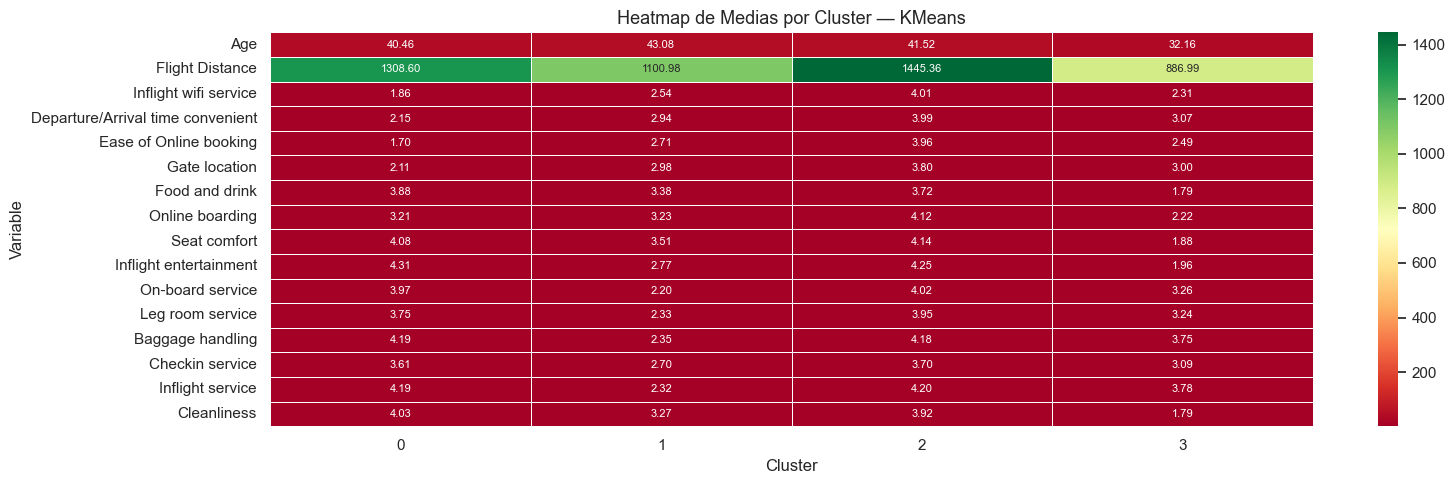

Gráfico guardado.


In [19]:
# Heatmap de medias por cluster
plt.figure(figsize=(16, 5))

numeric_means = df_kmeans.groupby('Cluster').mean(numeric_only=True)
numeric_means = numeric_means.drop(columns=['Arrival Delay in Minutes'])

sns.heatmap(numeric_means.T, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, annot_kws={'size': 8})
plt.title('Heatmap de Medias por Cluster — KMeans', fontsize=13)
plt.xlabel('Cluster')
plt.ylabel('Variable')
plt.tight_layout()
plt.savefig('heatmap_clusters.png', dpi=100, bbox_inches='tight')
plt.show()
print("Gráfico guardado.")

### 7.2 Análisis del Heatmap

El heatmap confirma visualmente los perfiles identificados y permite
destacar patrones clave:

**Cluster 0 — "Viajero de Negocios Exigente en Entretenimiento":**
Destaca por calificaciones altas en experiencia física a bordo
(entretenimiento, comodidad, limpieza) pero notoriamente bajas en
servicios digitales (wifi: 1.86, reserva online: 1.70). Es el cluster
con la brecha más pronunciada entre servicios físicos y digitales.

**Cluster 1 — "Viajero Moderado Insatisfecho con Cabina":**
Presenta calificaciones medias-bajas generalizadas en servicios de
cabina (servicio a bordo: 2.20, espacio para piernas: 2.33, manejo
de equipaje: 2.35). Es el cluster con el perfil más homogéneamente
mediocre, sin fortalezas claras.

**Cluster 2 — "Viajero Premium Satisfecho":**
Es el único cluster con calificaciones consistentemente altas en todas
las dimensiones, tanto digitales como físicas. Representa el segmento
de referencia que VuelaAlpes debe preservar y replicar.

**Cluster 3 — "Viajero Joven Personal Insatisfecho":**
El más crítico para VuelaAlpes: calificaciones muy bajas en comida
(1.79), comodidad (1.88), entretenimiento (1.96) y limpieza (1.79).
La distancia de vuelo más corta (887 km) y la edad más baja (32 años)
sugieren un segmento de viajeros personales en clase Eco que requiere
atención urgente.

**Nota sobre Flight Distance:**
La escala del heatmap está dominada por esta variable al estar en
una magnitud diferente (31–4963 km) frente a las calificaciones (0–5).
Esto se corrige en el gráfico de barras de la siguiente sección.

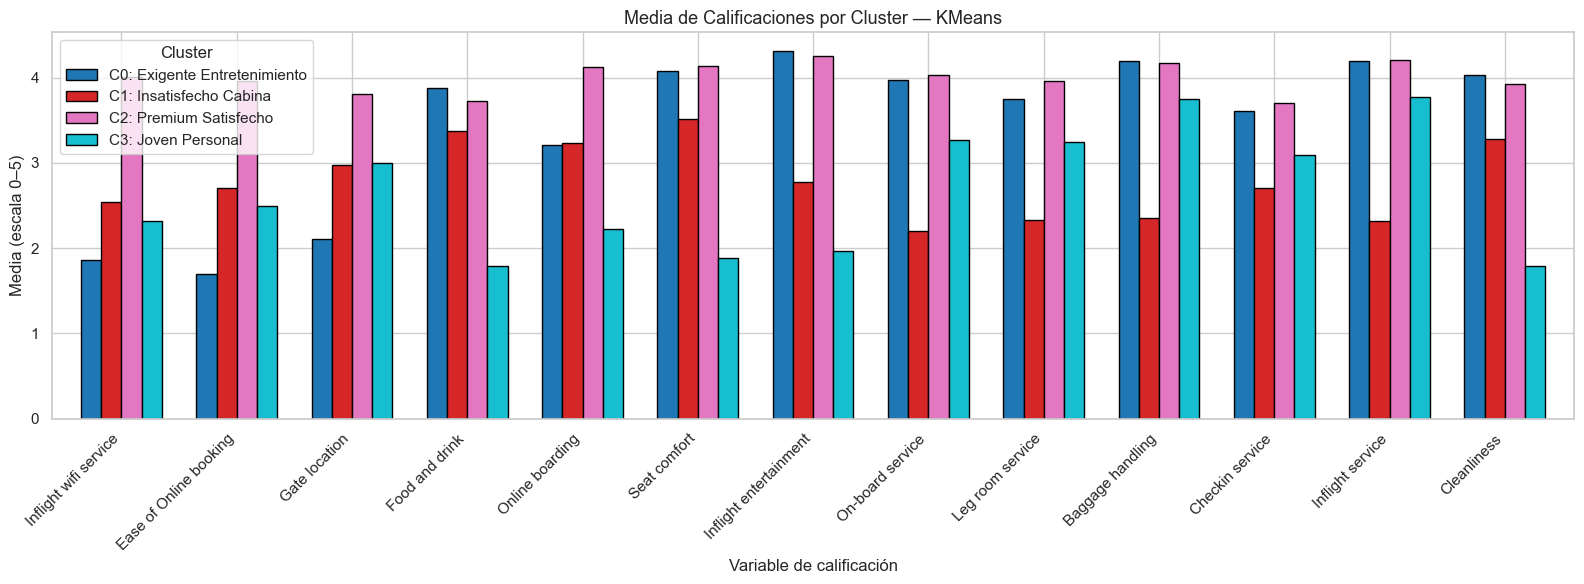

Gráfico guardado.


In [20]:
# Gráfico de barras por cluster para variables de calificación
rating_cols_plot = [
    'Inflight wifi service', 'Ease of Online booking', 'Gate location',
    'Food and drink', 'Online boarding', 'Seat comfort',
    'Inflight entertainment', 'On-board service', 'Leg room service',
    'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness'
]

means_plot = df_kmeans.groupby('Cluster')[rating_cols_plot].mean()

means_plot.T.plot(kind='bar', figsize=(16, 6), colormap='tab10', 
                  edgecolor='black', width=0.7)
plt.title('Media de Calificaciones por Cluster — KMeans', fontsize=13)
plt.xlabel('Variable de calificación')
plt.ylabel('Media (escala 0–5)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Cluster', labels=[
    'C0: Exigente Entretenimiento',
    'C1: Insatisfecho Cabina',
    'C2: Premium Satisfecho',
    'C3: Joven Personal'
])
plt.tight_layout()
plt.savefig('barras_clusters.png', dpi=100, bbox_inches='tight')
plt.show()
print("Gráfico guardado.")

### 7.3 Análisis del Gráfico de Barras por Cluster

El gráfico confirma y enriquece los perfiles identificados:

**Cluster 2 — "Viajero Premium Satisfecho" (rosado):**
Lidera en prácticamente todas las variables, especialmente en servicios
digitales (wifi: 4.01, reserva online: 3.96) donde los demás clusters
muestran debilidad. Es el segmento de referencia de VuelaAlpes.

**Cluster 0 — "Viajero de Negocios Exigente en Entretenimiento" (azul):**
Patrón muy característico: calificaciones altas en experiencia física
(entretenimiento: 4.31, comodidad: 4.08, manejo de equipaje: 4.19)
pero las más bajas del grupo en servicios digitales (wifi: 1.86,
reserva online: 1.70). La brecha entre lo físico y lo digital es la
más pronunciada de todos los clusters.

**Cluster 1 — "Viajero Moderado Insatisfecho con Cabina" (rojo):**
Calificaciones consistentemente bajas en servicios de cabina:
servicio a bordo (2.20), espacio para piernas (2.33) e inflight
service (2.32). Sin embargo, sus calificaciones digitales son
moderadas, lo que sugiere que el problema no es tecnológico sino
de atención en vuelo.

**Cluster 3 — "Viajero Joven Personal Insatisfecho" (cyan):**
El perfil más crítico: calificaciones muy bajas y homogéneas en
experiencia a bordo (comida: 1.79, entretenimiento: 1.96, limpieza:
1.79). Es el segmento con mayor potencial de mejora y el que más
urgentemente requiere intervención de VuelaAlpes.

**Implicaciones para VuelaAlpes:**
- **Innovación:** desarrollar mejoras digitales orientadas al Cluster 0
- **Capacitación:** enfocar en servicio de cabina para el Cluster 1
- **Calidad:** mejorar la experiencia física completa para el Cluster 3

## 8. Análisis de Resultados

En esta sección se responden las preguntas planteadas por VuelaAlpes
con base en los resultados obtenidos, se comparan los algoritmos
utilizados y se identifican las limitaciones del estudio.

### 8.1 Respuesta a las Preguntas del Laboratorio

**1. ¿Qué restricciones tiene cada algoritmo? ¿Cómo afectan la calidad?**

- **KMeans:** requiere especificar `k` previamente, asume clusters
  esféricos de tamaño similar y es sensible a outliers. En este caso
  produjo clusters equilibrados (2.390–2.795 registros) gracias al
  escalado previo con StandardScaler.

- **AgglomerativeClustering:** no requiere inicialización aleatoria
  pero su complejidad computacional es mayor O(n²). Produjo clusters
  más desbalanceados (1.010–3.562 registros) y métricas inferiores,
  sugiriendo que la estructura jerárquica no es la más adecuada para
  este dataset.

- **DBSCAN:** no requiere especificar `k` pero es extremadamente
  sensible a `eps` y `min_samples`. En este dataset de encuestas con
  variables Likert, la densidad es uniforme y no permite identificar
  regiones densas diferenciadas, colapsando el 96% de registros en
  un único cluster.

**2. ¿Qué criterios son importantes para la selección del algoritmo?**

Los criterios clave son: naturaleza de los datos (densidad, forma de
los clusters), escalabilidad al tamaño del dataset, necesidad de
especificar `k` previamente, sensibilidad a outliers y la
interpretabilidad de los resultados para el negocio. Para datasets
de encuestas con variables ordinales como este, KMeans con escalado
previo es la opción más robusta.

**3. ¿Cómo medir la calidad? ¿Cómo saber que el modelo tiene buena calidad?**

Se utilizaron tres métricas intrínsecas:
- **Silhouette Score:** KMeans obtuvo 0.1164, valor moderado que
  refleja la naturaleza continua y solapada de las variables de
  satisfacción. En datasets de encuestas, valores entre 0.1 y 0.3
  son esperables y aceptables.
- **Calinski-Harabasz:** KMeans obtuvo 1264.41, muy superior a
  Agglomerative (866.04) y DBSCAN (8.58), confirmando clusters
  más compactos y separados.
- **Davies-Bouldin:** KMeans obtuvo 2.27, inferior a Agglomerative
  (2.73), indicando mejor separación entre clusters.

**4. ¿Cómo varía la calidad si se aplican diferentes algoritmos?**

| Algoritmo | Silhouette | Calinski-Harabasz | Davies-Bouldin | Utilidad práctica |
|---|---|---|---|---|
| KMeans | 0.1164 | 1264.41 | 2.2700 | Alta |
| Agglomerative | 0.0696 | 866.04 | 2.7290 | Media |
| DBSCAN | 0.1540 | 8.58 | 1.2710 | Nula |

KMeans supera a Agglomerative en todas las métricas relevantes.
DBSCAN presenta métricas artificialmente favorables por el
desbalance extremo de sus clusters, pero carece de utilidad práctica.

**5. ¿Cómo interpretar el resultado de los algoritmos de agrupación?**

Los 4 clusters de KMeans representan perfiles reales de pasajeros:
- **C0 - Exigente en Entretenimiento:** satisfecho con experiencia
  física pero insatisfecho con servicios digitales
- **C1 - Insatisfecho con Cabina:** experiencia a bordo deficiente,
  en riesgo de perder fidelidad
- **C2 - Premium Satisfecho:** segmento más valioso, satisfecho en
  todas las dimensiones
- **C3 - Joven Personal Insatisfecho:** segmento crítico con
  experiencia física muy deficiente

### 8.2 Limitaciones y Sesgos

- El Silhouette Score global moderado (0.1164) indica que los clusters
  no están perfectamente separados, lo cual es esperable en datos de
  encuestas donde las percepciones de satisfacción son continuas.
- La varianza explicada por PCA 2D es solo del 34.85%, lo que
  significa que las visualizaciones capturan apenas un tercio de
  la información real del modelo.
- El dataset representa una muestra de 10.000 pasajeros que puede
  no ser representativa de toda la operación de VuelaAlpes.
- Las variables de calificación son subjetivas y pueden estar
  influenciadas por el momento en que se realizó la encuesta.